In [1]:
import numpy as np
import pickle
from scipy import stats
from scipy import signal
from matplotlib import pyplot as plt
import math
import matplotlib.colors as colors
import xarray as xr
import pandas as pd
import seaborn as sns
import json
import os
from scipy.ndimage import gaussian_filter1d
from fly2p_function_TQ.imaging_2p_preprocessing import combine_single_tiff, computeMotionShift, motionCorrection, low_pass_filter_TQ, high_pass_filter_TQ, averaging_frame,combine_single_tiff_ch1
from fly2p_function_TQ.imaging_2p_fictrac_imaging_alignment import downsample_heading_to_total_volume, offset_calculation,fictrack_signal_decoding,moving_wrapped_plot_by_offset

In [2]:
volume_cycle = 2836
volume_time = 0.10580
volume_rate = 1/volume_time
fictrack_sampling_rate = 50000
time_array_imaging = np.arange(volume_cycle)/volume_rate

In [4]:
voltage_recording = pd.read_csv('/home/tianhaoqiu/Desktop/TQfly548-001/TQfly548-001_Cycle00001_VoltageRecording_001.csv')

In [5]:
voltage_recording

,Time(ms),Start Trigger,Opto Trigger,FicTrac Cam Exp.,FicTrac Frame Proc.,Heading,Y/Index,Arena DAC1,Arena DAC2
0,0.00,1.072388,0.026550,0.020142,0.017090,6.958313,0.005493,6.974487,5.082397
1,0.02,1.143188,0.033264,0.020142,0.018311,6.961670,0.011292,6.967468,5.074768
2,0.04,1.204529,0.035095,0.020142,0.019226,6.961670,0.012512,6.973877,5.081482
3,0.06,1.269836,0.036926,0.021973,0.021362,6.962891,0.011292,6.971436,5.076904
4,0.08,1.328125,0.034485,0.020447,0.018005,6.961670,0.012817,6.972351,5.079956
...,...,...,...,...,...,...,...,...,...
15003797,300075.94,0.032654,0.032654,0.018311,0.016174,2.528381,0.010071,2.491760,5.076599
15003798,300075.96,0.032959,0.034180,0.018005,0.017090,2.527466,0.010681,2.495728,5.082092
15003799,300075.98,0.032959,0.032654,0.018616,0.019226,2.528076,0.009766,2.491455,5.076599
15003800,300076.00,0.032349,0.033264,0.018616,0.017395,2.527466,0.010681,2.496033,5.081177


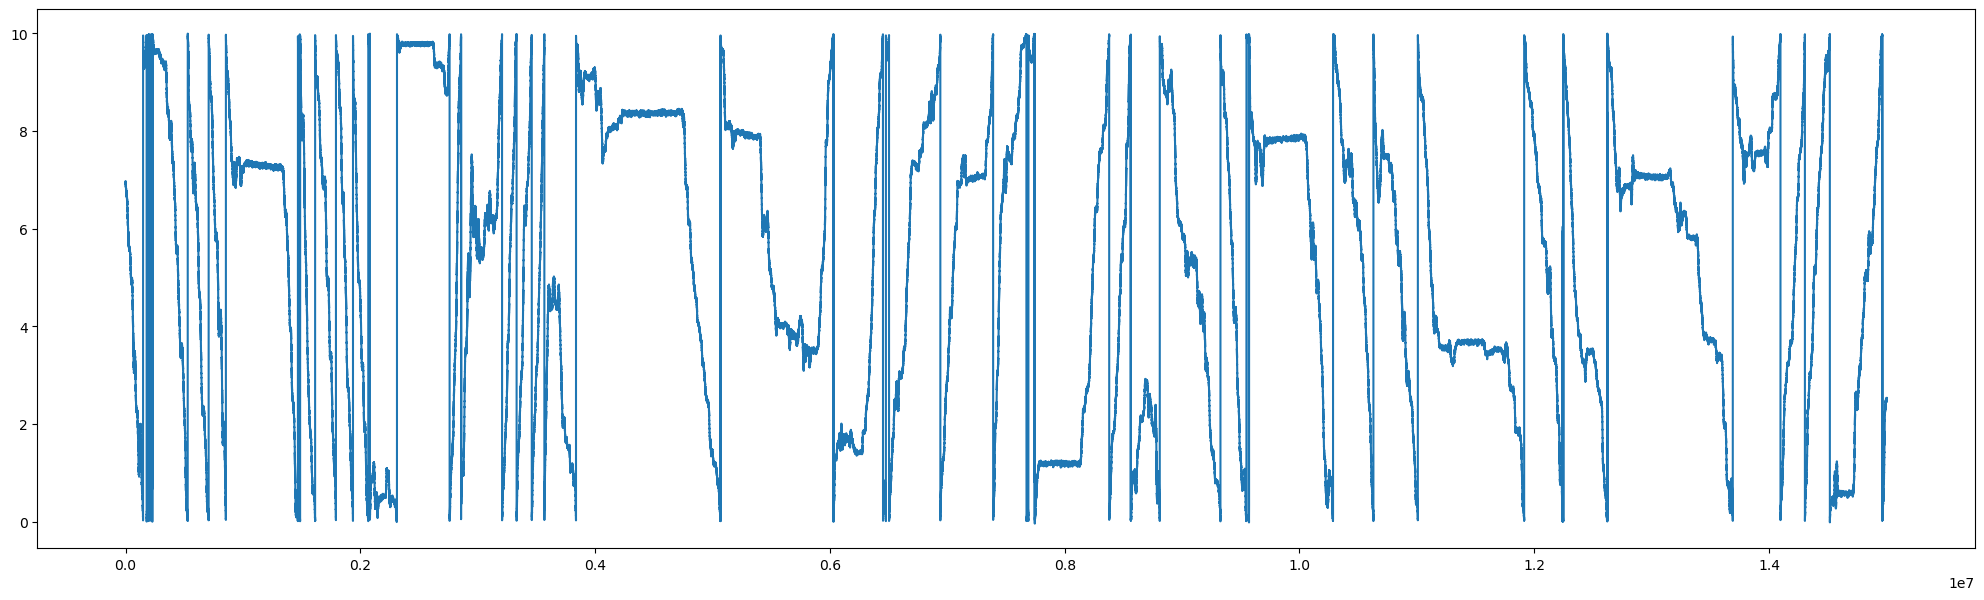

In [6]:
#Input4 = Heading, Input6 =x , Input7 =y
voltage_recording_heading = voltage_recording[' Heading']
voltage_recording_time = voltage_recording['Time(ms)']
plt.figure(figsize= (25,7))
plt.plot(voltage_recording[' Heading'])

In [7]:
#Read the fictrac raw .dat file and trial start/end info from Bruker
fictrac_data = pd.read_table('/home/tianhaoqiu/Desktop/Fictrac/TQfly548-12112024/fictrac-20241211_162110.dat', sep =',', header = None, names = ['frame counter', 'delta rotation vector x (cam)', 'delta rotation vector y (cam)','delta rotation vector z (cam)','delta rotation over score', 'delta rotaion vector 1 (lab)','delta rotaion vector 2 (lab)', 'delta rotaion vector 3 (lab)', 'absolute rotation vector 1 (cam)','absolute rotation vector 2 (cam)','absolute rotation vector 3 (cam)','absolute rotation vector 1 (lab)','absolute rotation vector 2 (lab)','absolute rotation vector 3 (lab)','integrated x', 'integrated y','integrated heading','animal movement direcrtion','animal movement speed', 'integrated forward motion','integrated side motion','timestamp','sequence counter','delta timestamp','alt.timestamp'] )
fictrac_data

,frame counter,delta rotation vector x (cam),delta rotation vector y (cam),delta rotation vector z (cam),delta rotation over score,delta rotaion vector 1 (lab),delta rotaion vector 2 (lab),delta rotaion vector 3 (lab),absolute rotation vector 1 (cam),absolute rotation vector 2 (cam),...,integrated y,integrated heading,animal movement direcrtion,animal movement speed,integrated forward motion,integrated side motion,timestamp,sequence counter,delta timestamp,alt.timestamp
0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,6.762589e+15,0,0,5.887130e+07
1,1,0.000536,0.000974,0.003283,4450.048159,0.002495,0.002303,0.000696,0.000536,0.000974,...,-0.002495,6.282489,5.457945,0.003395,0.002303,-0.002495,6.762589e+15,1,2126058,5.887130e+07
2,2,-0.002958,0.001458,0.000805,4381.407461,0.002426,-0.001958,0.001343,-0.002420,0.002437,...,-0.004919,6.281146,4.033312,0.003118,0.000345,-0.004921,6.762589e+15,2,2126506,5.887130e+07
3,3,0.010211,-0.000469,-0.000510,4141.471774,-0.006137,0.008185,-0.000283,0.007791,0.001948,...,0.001202,6.281429,0.643339,0.010230,0.008530,0.001216,6.762589e+15,3,2125569,5.887130e+07
4,4,-0.004291,-0.000319,0.011946,4230.694250,0.012245,0.003054,-0.001400,0.003487,0.001683,...,-0.011046,6.282830,4.956774,0.012620,0.011584,-0.011029,6.762589e+15,4,2126506,5.887130e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1257900,1257900,-0.001448,-0.001262,-0.002250,2344.025367,-0.001156,-0.002498,-0.001084,2.533747,0.829007,...,0.815695,0.283216,2.708324,0.002753,-17.483545,-202.570510,6.765263e+15,1257900,2125813,6.154574e+07
1257901,1257901,-0.000718,-0.000438,-0.002691,2257.209613,-0.001862,-0.002107,-0.000216,2.533116,0.825524,...,0.816894,0.283432,2.417878,0.002811,-17.485652,-202.568648,6.765263e+15,1257901,2126262,6.154574e+07
1257902,1257902,0.001194,0.000358,-0.003225,2344.025367,-0.003304,-0.000785,0.000649,2.534691,0.820713,...,0.819847,0.282782,1.803928,0.003396,-17.486437,-202.565344,6.765263e+15,1257902,2126058,6.154574e+07
1257903,1257903,0.000999,0.000270,-0.003160,2430.841121,-0.003149,-0.000915,0.000554,2.536027,0.816048,...,0.822616,0.282229,1.853500,0.003279,-17.487351,-202.562195,6.765263e+15,1257903,2125813,6.154574e+07


In [8]:
with open('/home/tianhaoqiu/Desktop/Fictrac/TQfly548-12112024/TQfly548_scan0.pkl', 'rb') as f:
    fictracinfo = pickle.load(f)
fictracinfo

{'start': [168274],
 'opto': [],
 'abort': [312662],
 'start_trig_falling_edge': []}

In [9]:
#This for all fly before TQfly235
#start_frame_index = fictracinfo['start_trig_falling_edge'][0] - 1
start_frame_index = fictracinfo['start'][0] - 1
abort_frame_index = fictracinfo['abort'][0]

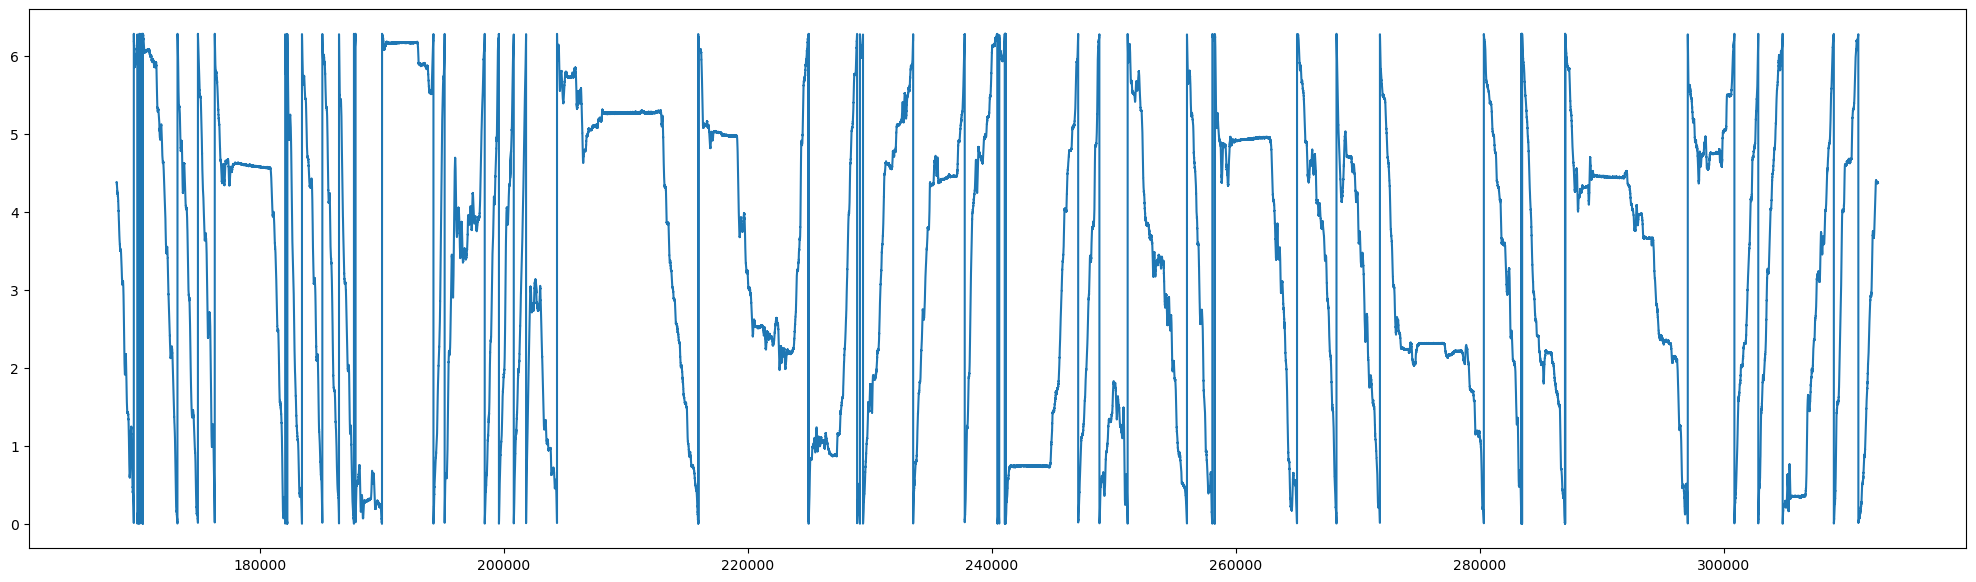

In [10]:
# the scanning start actually one frame before the falling_edge
fictrac_heading = fictrac_data['integrated heading']
fictrac_integrated_x = fictrac_data['integrated x']
fictrac_integrated_y = fictrac_data['integrated y']
plt.figure(figsize= (25,7))
plt.plot(fictrac_heading[start_frame_index:abort_frame_index ])

In [11]:
#change it to binary
fictrac_frame_proc = voltage_recording[' FicTrac Frame Proc.']
pinn_signal = np.zeros(len(fictrac_frame_proc))
for i in range(len(fictrac_frame_proc)):
    if fictrac_frame_proc[i] < 1:
        pinn_signal[i] = 0
    else:
        pinn_signal[i] = 1

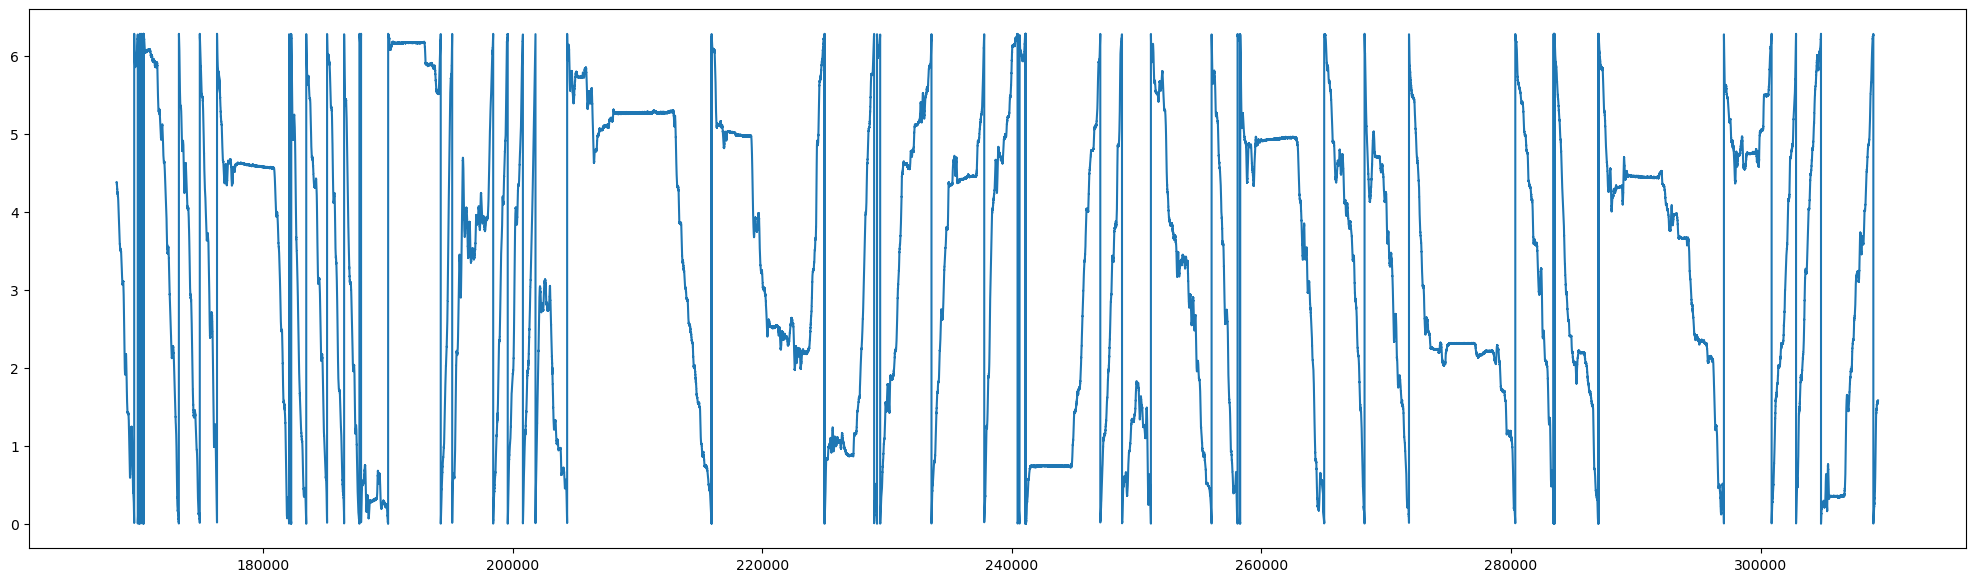

In [12]:
#find every time pinn value is up to 1(locked to each scanning frame)
up_index = np.argwhere(np.diff(pinn_signal)==1)
plt.figure(figsize= (25,7))
plt.plot(fictrac_heading[start_frame_index:start_frame_index+len(up_index)])
fictrac_heading[start_frame_index:start_frame_index+len(up_index)].shape
plt.show()

In [13]:
behavior_sampling_rate =int(np.ceil(len(up_index)/(volume_cycle*volume_time)))

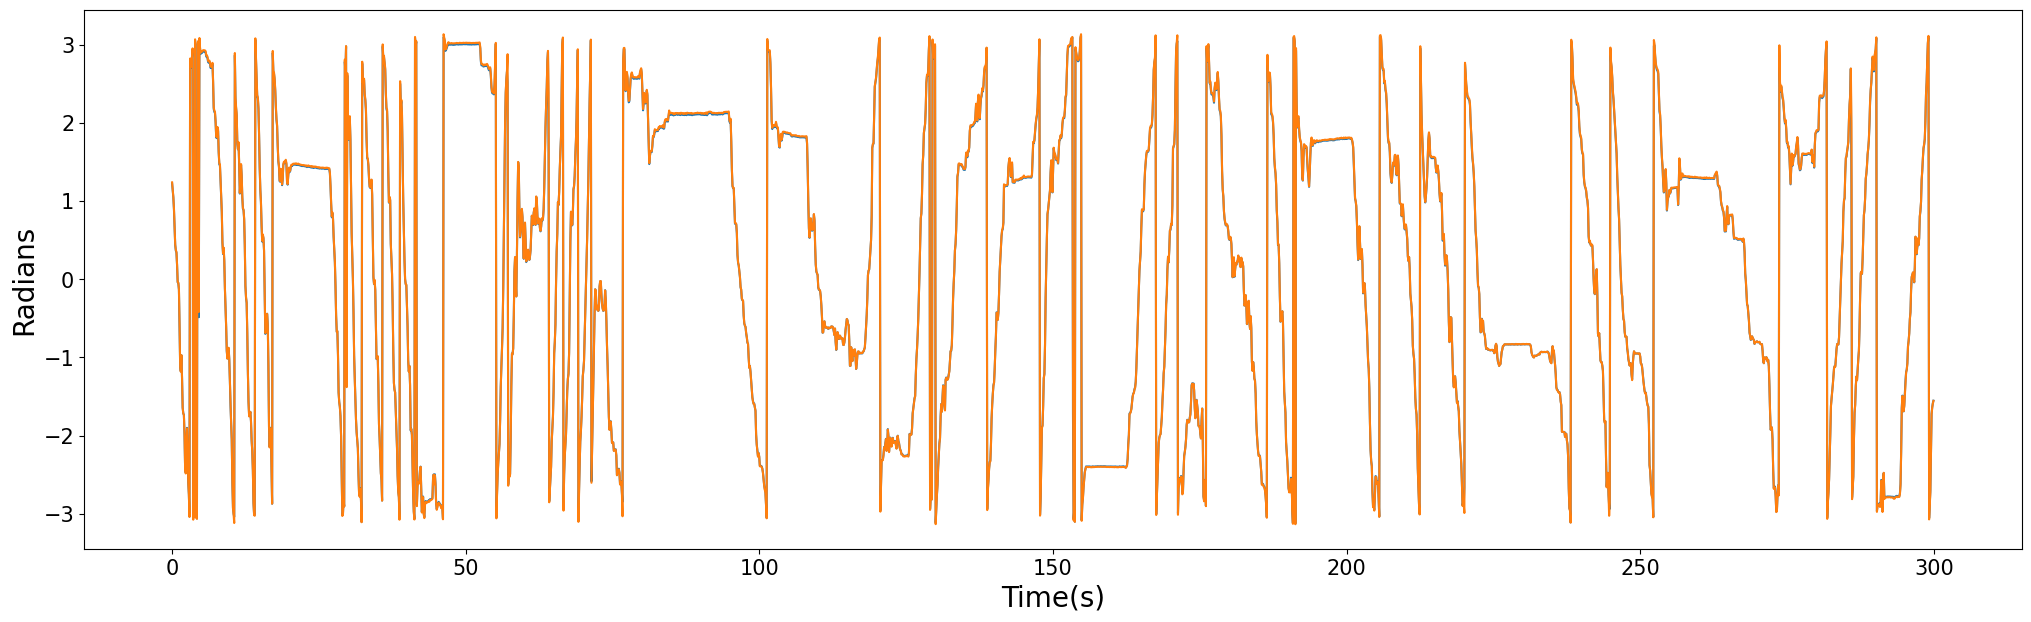

In [14]:
heading_array = voltage_recording [' Heading']
time_array_initial_fictrac = np.arange(len(heading_array))/fictrack_sampling_rate
head_array_filtered = low_pass_filter_TQ(heading_array, 100 ,fictrack_sampling_rate)
head_array_filtered = low_pass_filter_TQ(head_array_filtered, 100 ,fictrack_sampling_rate)
head_array_downsampled = downsample_heading_to_total_volume(volume_cycle, head_array_filtered)

test = fictrac_heading[start_frame_index:start_frame_index+len(up_index)]
test_filtered = low_pass_filter_TQ(test, 100 ,behavior_sampling_rate)
test_filtered = low_pass_filter_TQ(test_filtered, 100 ,behavior_sampling_rate)
test_filtered_downsampled = downsample_heading_to_total_volume(volume_cycle, test_filtered)

plt.figure(figsize= (25,7))
plt.plot(time_array_imaging,head_array_downsampled*np.pi*2/10-np.pi)
#plt.plot(time_array_imaging,test_filtered_downsampled-np.pi)
plt.plot(time_array_imaging,test_filtered_downsampled-np.pi)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.xlabel('Time(s)', fontsize=20)
plt.ylabel('Radians', fontsize=20)
plt.show()

In [15]:
import statsmodels.api as sm
correlate_array_fictrac_voltageRecording= np.zeros(10000)
for i in range(len(correlate_array_fictrac_voltageRecording)):
    test_fictrac_behavior = fictrac_heading[start_frame_index-i:start_frame_index-i+len(up_index)]
    test_fictrac_behavior = low_pass_filter_TQ(test_fictrac_behavior, 100 ,behavior_sampling_rate)
    test_fictrac_behavior= low_pass_filter_TQ(test_fictrac_behavior, 100 ,behavior_sampling_rate)
    test_fictrac_behavior = downsample_heading_to_total_volume(volume_cycle, test_fictrac_behavior)
    correlate_array_fictrac_voltageRecording[i] = np.correlate(test_fictrac_behavior-np.pi,head_array_downsampled*np.pi*2/10-np.pi)
np.argwhere(correlate_array_fictrac_voltageRecording==np.max(correlate_array_fictrac_voltageRecording))

array([[0]])

In [16]:
corrected_frame =  np.argwhere(correlate_array_fictrac_voltageRecording==np.max(correlate_array_fictrac_voltageRecording))[0][0]
corrected_frame = 0
start_frame_index_corrected = start_frame_index - corrected_frame

In [17]:
corrected_frame 

0

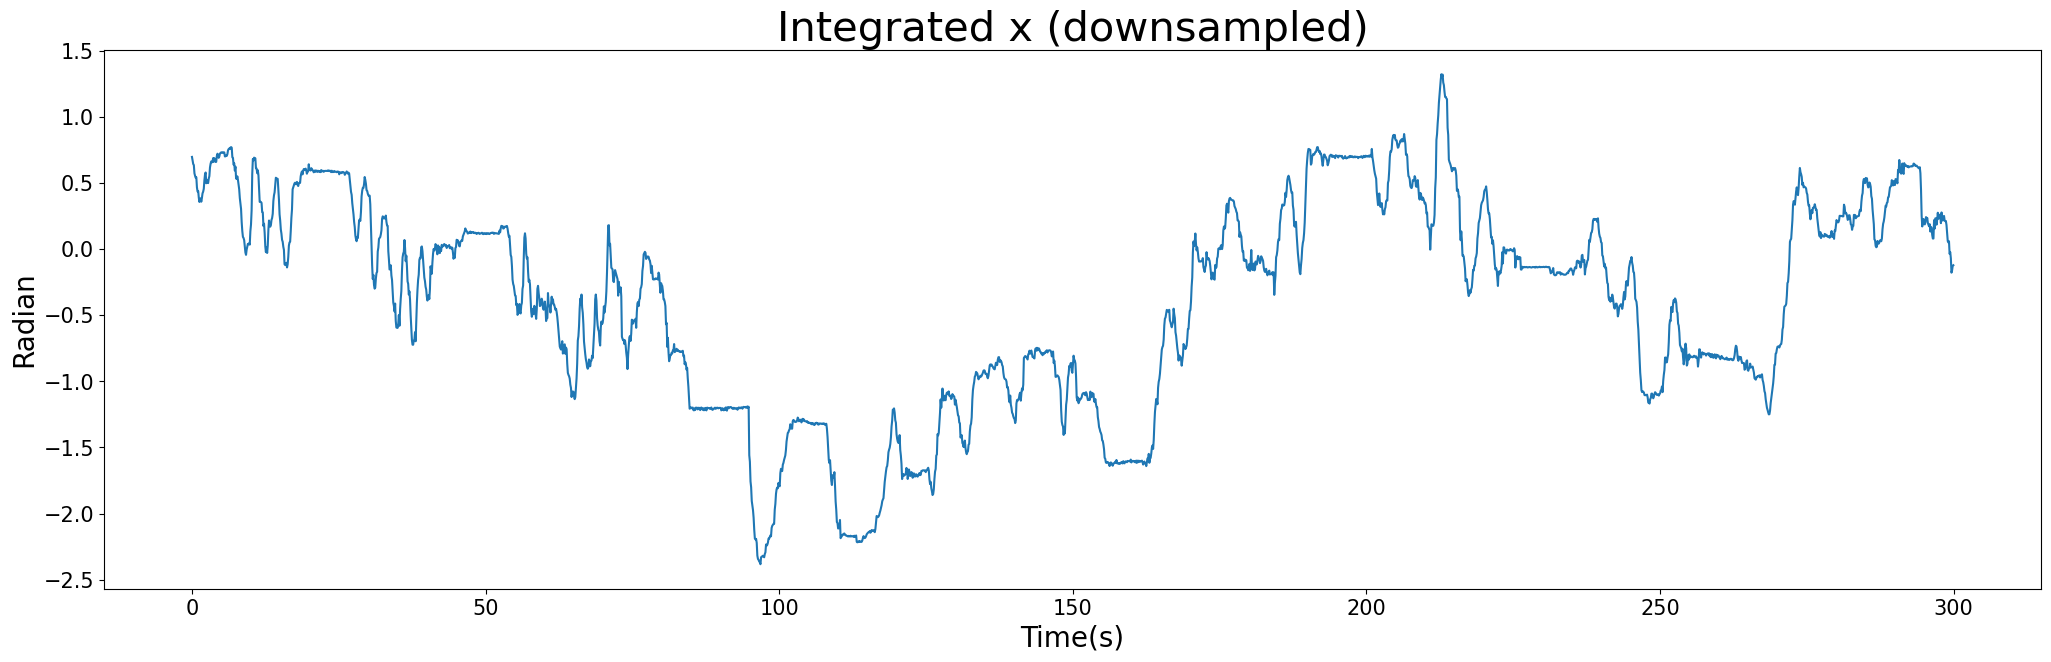

In [18]:
fictrac_integrated_x_filtered = low_pass_filter_TQ(fictrac_integrated_x[start_frame_index_corrected :start_frame_index_corrected +len(up_index)],100,behavior_sampling_rate)
fictrac_integrated_x_filtered = low_pass_filter_TQ(fictrac_integrated_x_filtered ,100,behavior_sampling_rate)
fictrac_integrated_x_filtered_downsampled = downsample_heading_to_total_volume(volume_cycle, fictrac_integrated_x_filtered)
fictrac_integrated_y_filtered = low_pass_filter_TQ(fictrac_integrated_y[start_frame_index_corrected :start_frame_index_corrected +len(up_index)],100,behavior_sampling_rate)
fictrac_integrated_y_filtered = low_pass_filter_TQ(fictrac_integrated_y_filtered ,100,behavior_sampling_rate)
fictrac_integrated_y_filtered_downsampled = downsample_heading_to_total_volume(volume_cycle, fictrac_integrated_y_filtered)
plt.figure(figsize= (25,7))
plt.plot(time_array_imaging,fictrac_integrated_x_filtered_downsampled)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.xlabel('Time(s)', fontsize=20)
plt.ylabel('Radian', fontsize=20)
plt.title('Integrated x (downsampled)', fontsize =30)
plt.show()

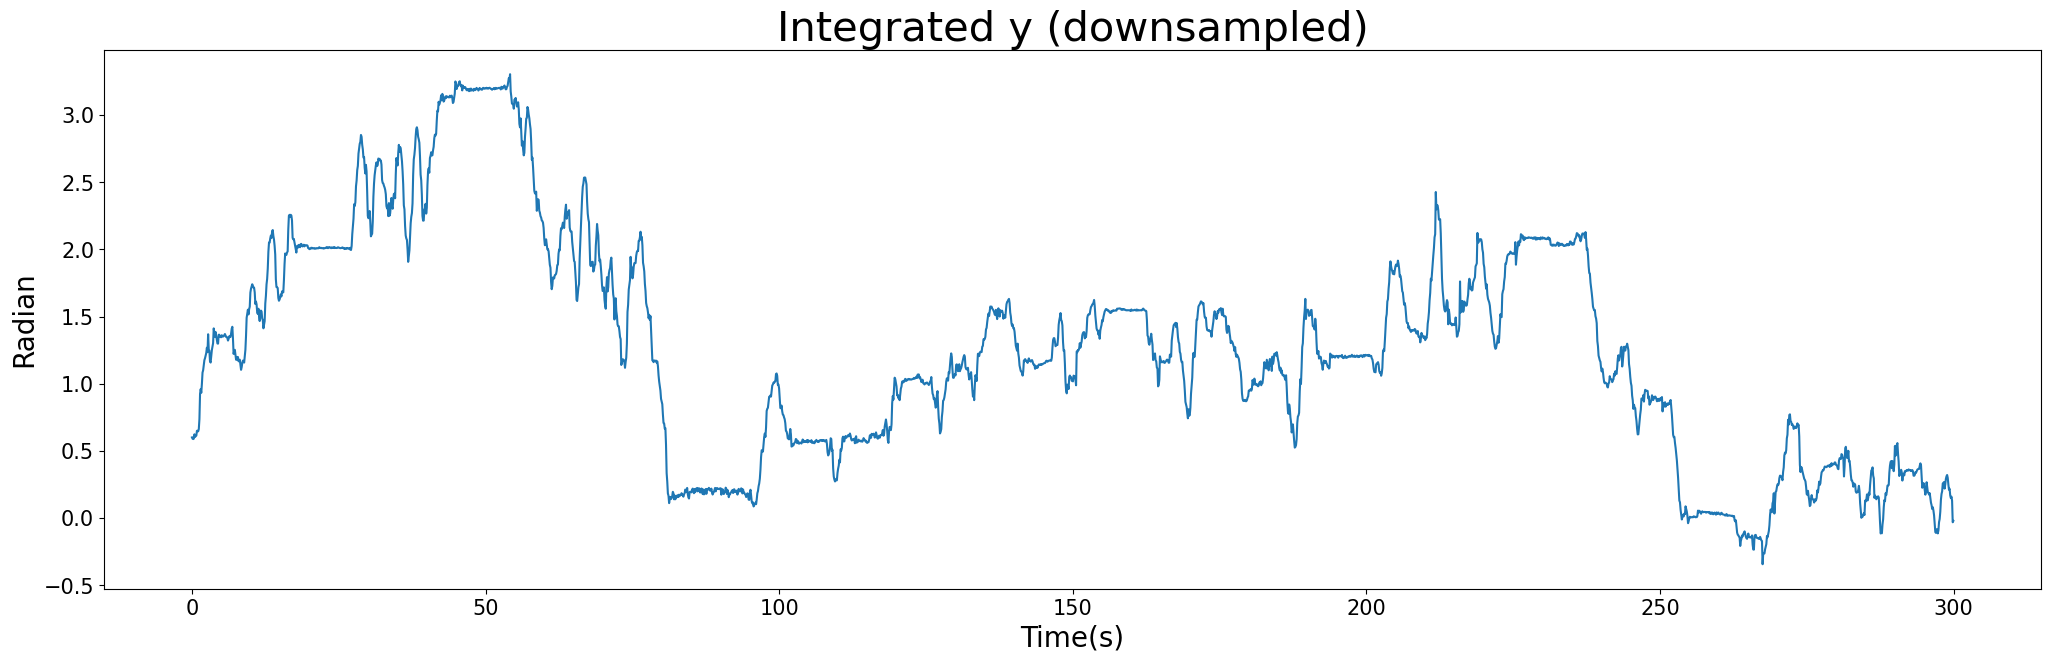

In [19]:
plt.figure(figsize= (25,7))
plt.plot(time_array_imaging,fictrac_integrated_y_filtered_downsampled)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.xlabel('Time(s)', fontsize=20)
plt.ylabel('Radian', fontsize=20)
plt.title('Integrated y (downsampled)', fontsize =30)
plt.show()

In [20]:
fictrac_heading_corrected = fictrac_heading[start_frame_index_corrected :start_frame_index_corrected +len(up_index)]
fictrac_heading_corrected_filtered = low_pass_filter_TQ(fictrac_heading_corrected, 100 ,behavior_sampling_rate)
fictrac_heading_corrected_filtered = low_pass_filter_TQ(fictrac_heading_corrected_filtered, 100 ,behavior_sampling_rate)
fictrac_heading_corrected_filtered_downsampled = downsample_heading_to_total_volume(volume_cycle, fictrac_heading_corrected_filtered)

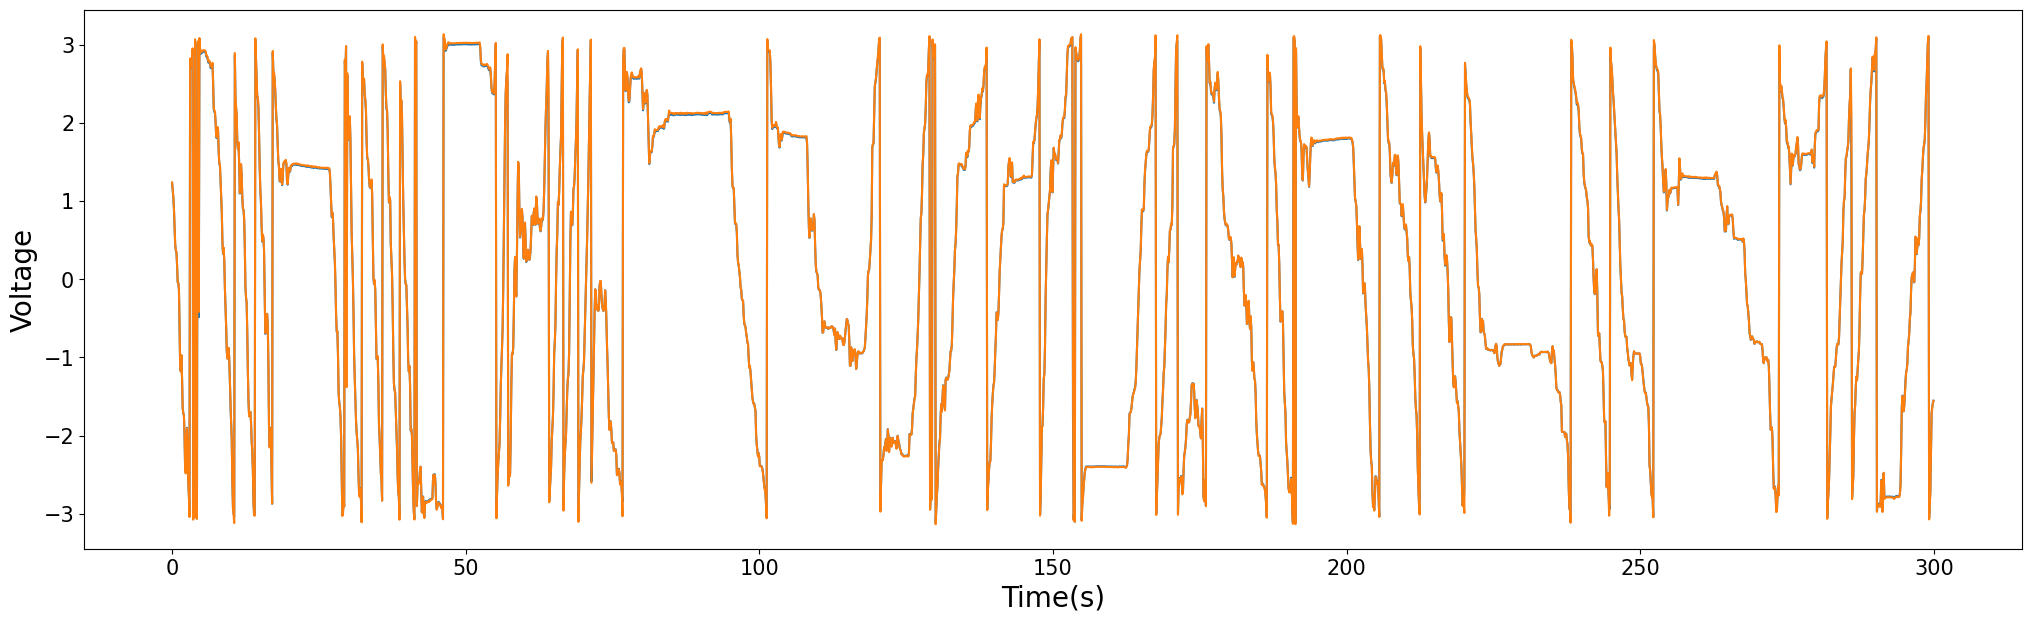

In [21]:
plt.figure(figsize= (25,7))
plt.plot(time_array_imaging,(head_array_downsampled*np.pi*2/10-np.pi))
plt.plot(time_array_imaging,(fictrac_heading_corrected_filtered_downsampled-np.pi))
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.xlabel('Time(s)', fontsize=20)
plt.ylabel('Voltage', fontsize=20)
plt.show()

In [22]:
import numpy as np

def compute_forward_sideways_velocity(
    x, y, heading, frame_dt, 
    use_centered_heading=True
):
    """
    Compute forward and sideways velocity from FicTrac integrated x/y and heading.

    Parameters
    ----------
    x : array_like, shape (T,)
        FicTrac integrated X (already downsampled to imaging frames).
    y : array_like, shape (T,)
        FicTrac integrated Y (already downsampled to imaging frames).
    heading : array_like, shape (T,)
        FicTrac heading in radians, same length and alignment as x and y.
    frame_dt : float
        Time between imaging frames in seconds (e.g., 0.1 for 10 Hz imaging).
    use_centered_heading : bool, optional
        If True (default), uses the average of heading[t] and heading[t-1]
        for the velocity between frames. If False, uses heading[1:] only.

    Returns
    -------
    v_forward : np.ndarray, shape (T,)
        Forward velocity in units of x/y per second.
        First sample is np.nan because there is no previous frame to diff.
    v_sideways : np.ndarray, shape (T,)
        Sideways (lateral) velocity in units of x/y per second.
        Positive = to the fly's left, negative = to the fly's right.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    heading = np.asarray(heading)

    assert x.shape == y.shape == heading.shape, "x, y, heading must have same shape"
    assert x.ndim == 1, "Inputs must be 1D time series"

    # Frame-to-frame displacement in world coordinates
    dx = np.diff(x)
    dy = np.diff(y)

    # Choose heading to associate with each displacement
    if use_centered_heading:
        # Average heading between frames to better approximate direction
        h_mid = np.unwrap(heading)  # unwrap to avoid jumps at +/-pi
        h_mid = 0.5 * (h_mid[1:] + h_mid[:-1])
    else:
        h_mid = heading[1:]

    # Forward unit vector in world coordinates
    cos_h = np.cos(h_mid)
    sin_h = np.sin(h_mid)

    # Project displacement onto forward axis to get forward distance per frame
    # forward = dx * cos(h) + dy * sin(h)
    forward_disp = dx * cos_h + dy * sin_h

    # Sideways axis = rotate forward vector by -90deg
    # sideways = (-dx * sin(h) + dy * cos(h))
    sideways_disp = -dx * sin_h + dy * cos_h

    # Convert per-frame displacements to velocities (units / s)
    v_forward_step = forward_disp / frame_dt
    v_sideways_step = sideways_disp / frame_dt

    # Pad with NaN at the beginning to match original length T
    v_forward = np.empty_like(heading, dtype=float)
    v_sideways = np.empty_like(heading, dtype=float)
    v_forward[:] = np.nan
    v_sideways[:] = np.nan
    v_forward[1:] = v_forward_step
    v_sideways[1:] = v_sideways_step

    return v_forward, v_sideways


In [23]:
# Example usage
x = fictrac_integrated_x_filtered_downsampled
y = fictrac_integrated_y_filtered_downsampled
hd = fictrac_heading_corrected_filtered_downsampled-np.pi   # radians
frame_dt = volume_time    # e.g., imaging_fps = 10

v_forward, v_sideways = compute_forward_sideways_velocity(x, y, hd, frame_dt)


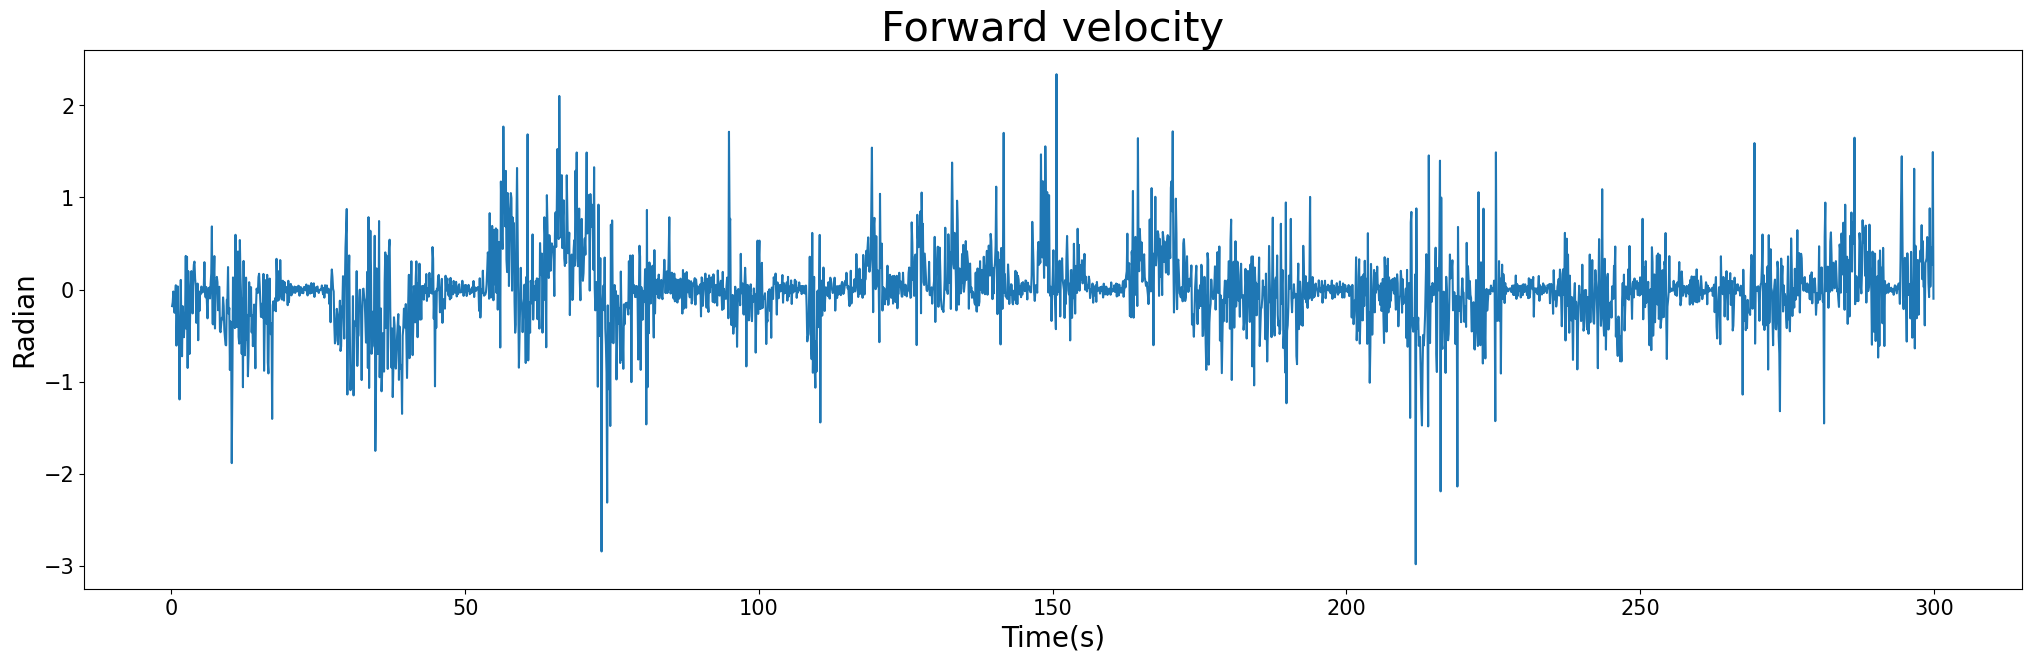

In [24]:
plt.figure(figsize= (25,7))
plt.plot(time_array_imaging,v_forward)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.xlabel('Time(s)', fontsize=20)
plt.ylabel('Radian', fontsize=20)
plt.title('Forward velocity', fontsize =30)
plt.show()

Mean v_forward: 0.002568939659221782


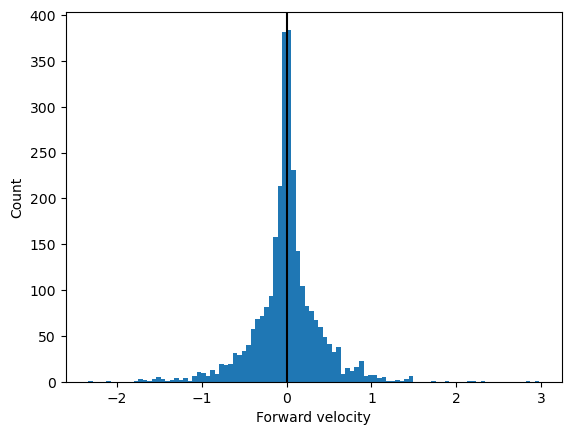

Mean v_forward when moving: 0.008681657512468605


In [27]:
x = fictrac_integrated_x_filtered_downsampled
y = fictrac_integrated_y_filtered_downsampled
hd = fictrac_heading_corrected_filtered_downsampled
frame_dt = volume_time 

v_forward, v_sideways = compute_forward_sideways_velocity(x, y, hd, frame_dt)

# 1) Mean forward velocity (should usually be >= 0 if fly mostly walks forward)
print("Mean v_forward:", np.nanmean(v_forward))

# 2) Look at distribution
import matplotlib.pyplot as plt
plt.hist(v_forward[np.isfinite(v_forward)], bins=100)
plt.axvline(0, color='k')
plt.xlabel("Forward velocity")
plt.ylabel("Count")
plt.show()

# 3) Focus only on clearly moving frames
speed = np.sqrt(np.diff(x, prepend=x[0])**2 + np.diff(y, prepend=y[0])**2) / frame_dt
moving = speed > np.percentile(speed, 70)   # top 30% of speeds

print("Mean v_forward when moving:", np.nanmean(v_forward[moving]))


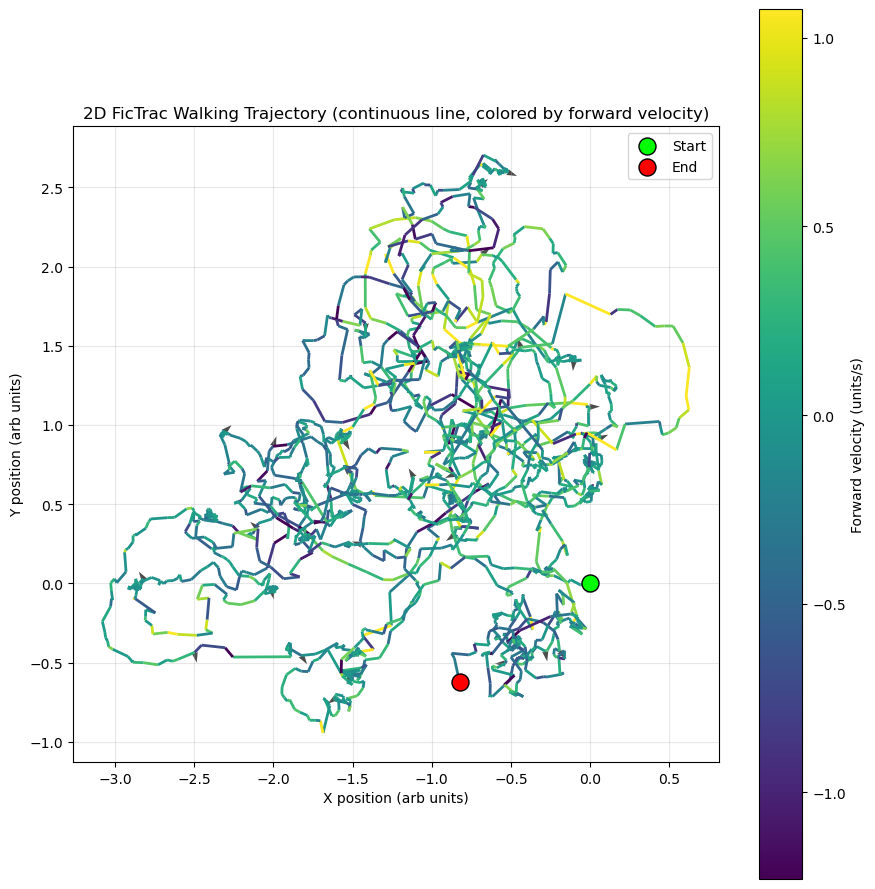

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# -------------------------------------------------------
# Function to compute velocities (same as before)
# -------------------------------------------------------

def compute_forward_sideways_velocity(
    x, y, heading, frame_dt, use_centered_heading=True
):
    x = np.asarray(x)
    y = np.asarray(y)
    heading = np.asarray(heading)

    dx = np.diff(x)
    dy = np.diff(y)

    if use_centered_heading:
        h_mid = np.unwrap(heading)
        h_mid = 0.5 * (h_mid[1:] + h_mid[:-1])
    else:
        h_mid = heading[1:]

    cos_h = np.cos(h_mid)
    sin_h = np.sin(h_mid)

    forward_disp = dx * cos_h + dy * sin_h
    sideways_disp = -dx * sin_h + dy * cos_h

    v_forward_step = forward_disp / frame_dt
    v_sideways_step = sideways_disp / frame_dt

    v_forward = np.empty_like(heading)
    v_sideways = np.empty_like(heading)
    v_forward[:] = np.nan
    v_sideways[:] = np.nan
    v_forward[1:] = v_forward_step
    v_sideways[1:] = v_sideways_step

    return v_forward, v_sideways


# -------------------------------------------------------
# Continuous-line trajectory plot
# -------------------------------------------------------

def plot_fictrac_trajectory_lines(
    x, y, heading, frame_dt,
    downsample_quiver=50,
    v_clip_percentile=99,
    cmap="viridis"
):
    # Center trajectory
    x0 = x - x[0]
    y0 = y - y[0]

    # Compute forward velocity
    v_forward, _ = compute_forward_sideways_velocity(x, y, heading, frame_dt)

    # Clip for nicer color scaling
    finite_v = v_forward[np.isfinite(v_forward)]
    vmax = np.percentile(finite_v, v_clip_percentile)
    vmin = np.percentile(finite_v, 100 - v_clip_percentile)
    v_plot = np.clip(v_forward, vmin, vmax)

    # Build line segments for LineCollection
    points = np.array([x0, y0]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    fig, ax = plt.subplots(figsize=(9, 9))

    # Colored continuous line
    lc = LineCollection(segments, cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    lc.set_array(v_plot)
    lc.set_linewidth(2.0)
    ax.add_collection(lc)

    # Scatter for start/end points
    ax.scatter(x0[0], y0[0], s=150, c='lime', edgecolor='black', label="Start", zorder=3)
    ax.scatter(x0[-1], y0[-1], s=150, c='red', edgecolor='black', label="End", zorder=3)

    # Optional heading arrows
    if downsample_quiver and downsample_quiver > 0:
        idx = np.arange(0, len(x0), downsample_quiver)
        hx = np.cos(heading[idx])
        hy = np.sin(heading[idx])
        ax.quiver(
            x0[idx], y0[idx],
            hx, hy,
            angles='xy', scale_units='xy', scale=15,
            width=0.0035, color='black', alpha=0.7
        )

    # Formatting
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("X position (arb units)")
    ax.set_ylabel("Y position (arb units)")
    ax.set_title("2D FicTrac Walking Trajectory (continuous line, colored by forward velocity)")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right")

    # Colorbar
    cbar = fig.colorbar(lc, ax=ax)
    cbar.set_label("Forward velocity (units/s)")

    plt.tight_layout()
    plt.show()



# ---------- example call with your variables ----------

# Your existing variables:
# fictrac_integrated_x_filtered_downsampled
# fictrac_integrated_y_filtered_downsampled
# fictrac_heading_corrected_filtered_downsampled
# imaging interval is 0.10 s -> frame_dt = 0.10

frame_dt = volume_time

plot_fictrac_trajectory_lines(
    fictrac_integrated_x_filtered_downsampled,
    fictrac_integrated_y_filtered_downsampled,
    fictrac_heading_corrected_filtered_downsampled,
    frame_dt,
    downsample_quiver=100  # change to taste
)
